# Multi-Telescope Configuration

## Telescope Groups

The 32 telescopes are arranged in 4 groups of 8 telescopes:
- all 8 cameras of each group have exactly the same field-of-view</li>
- the lines-of-sight of the 4 groups are offset by an angle of 9.2° from the PLM +Z axis</li>

<img src="telescopeGroups.png">

→ per group:

- same tilt & azimuth angle
- all telescopes within the same group will observe the target with the same CCD

## Tilt & Azimuth Angle

<img src="tiltAzimuth.png">

## Resulting FOV Configuration

<img src="fov.png">

# Scripting Multi-Telescope Configuration in Python

In [19]:
%matplotlib inline
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (10,10)

## Where is my stuff located?

In [20]:
import os
baseDir = os.getenv("PLATO_PROJECT_HOME")
workDir = os.getenv("PLATO_WORKDIR")
print(workDir)
print(baseDir)

import sys
sys.path.append(baseDir + "/python")

/Users/sara/work/Instrumentation/Plato/workdir/
/Users/sara/work/Instrumentation/Plato/softwareDevelopment/PlatoSim3


## Importing

In [21]:
import os
import math
from math import radians, degrees
import numpy as np
from simulation import Simulation
import referenceFrames as rf
import plot
from referenceFrames import CCD
from importlib import reload

## Where to find the input parameters and where to store the output?

In [22]:
inputDir = baseDir + "/inputfiles"
inputFile   = inputDir + "/inputfile.yaml"

outputDir   = workDir
outputPrefix = "MultiTelescopeConfiguration"

## Configuration Parameters

### Observing Parameters

In [23]:
raPlatform  = 10.0                      # Platform right ascension pointing coordinate [degrees]
decPlatform = 10.0                      # Platform declination pointing coordinate [degrees]

raSubfield  = 10.0                      # Right ascension on which to centre the sub-field [degrees]
decSubfield = 10.0                      # Declination on which to centre the sub-field [degrees]

numTelescopeGroups = 4                  # Number of telescope groups
numTelescopesPerGroup = 8               # Number of telescopes per group

### Star catalog

One star only, of V=9.5 magnitude.

In [24]:
catalog = np.array([[raSubfield, decSubfield, 9.5]])

In [25]:
starCatalogFileName = outputPrefix + "_starcatalog.txt"

In [26]:
starCatalogPath = outputDir + starCatalogFileName

In [27]:
np.savetxt(starCatalogPath, catalog)

In [28]:
print(starCatalogPath)

/Users/sara/work/Instrumentation/Plato/workdir/MultiTelescopeConfiguration_starcatalog.txt


### Telescope Parameters

In [29]:
driftSeed = 1433429158                  # Random seed for telescope drift (different for each telescope!)

### CCD Parameters (different for each telescope)

In [30]:
readoutNoiseSeed =  1424949740          # Random seed for the readout noise
photonNoiseSeed = 1433320336            # Random seed for the photon noise
flatfieldSeed = 1433320381              # Random seed for the flatfield

### Sub-Field Parameters

In [31]:
numColumnsSubField = 10                 # Number of columns in the modelled sub-field [pixels]
numRowsSubField    = 10                 # Number of rows in the modelled sub-field [pixels]

## Simulations

For each telescope in each group:
- platform pointing & (tilt, azimuth) -> telescope pointing
- which CCD selected?
- sub-field falls entirely on selected CCD -> simulation


In [32]:
raTelescopePointings = []
decTelescopePointings = []

# Loop over all groups of telescopes

for group in range(numTelescopeGroups):
    
    # Loop over all telescopes in the current group
    
    for telescope in range(numTelescopesPerGroup):
        
        print("Processing telescope {0} of group {1}".format(telescope + 1, group + 1))
        
        telescopeIndex = numTelescopesPerGroup * group + telescope
        
        # Output will be stored in multiTelescopeConfiguration_group<group>_telescope<telescope>
        
        outputFilePrefix = outputPrefix + "_group" +  "{0:02d}".format(group+1)           \
                                        + "_telescope" + "{0:02d}".format(telescope+1)
        sim = Simulation(outputFilePrefix, inputFile)
        sim.outputDir = outputDir
        
        sim["ObservingParameters/StarCatalogFile"] = starCatalogPath
        
        azimuthAngles = sim["CameraGroups/AzimuthAngle"]
        tiltAngles = sim["CameraGroups/TiltAngle"]
        solarPanelOrientation = float(sim["Platform/SolarPanelOrientation"])      # [deg]
        
        # Compute the telescope pointing, based on the platform pointing and the tilt and azimuth angle 
        # of the telescope
        
        raSun, decSun = rf.sunSkyCoordinatesAwayfromPlatformPointing(radians(raPlatform),   \
                                                                     radians(decPlatform),  \
                                                                     radians(solarPanelOrientation))
        raTelescope, decTelescope = rf.platformToTelescopePointingCoordinates(radians(raPlatform),           \
                                                                              radians(decPlatform),          \
                                                                              raSun, decSun,                 \
                                                                              radians(azimuthAngles[group]), \
                                                                              radians(tiltAngles[group]))
        if telescope == 0:
            raTelescopePointings.append(degrees(raTelescope))
            decTelescopePointings.append(degrees(decTelescope))
        
        print("Platform pointing: {0}, {1}".format(raPlatform, decPlatform))
        print("Telescope pointing: {0}, {1}".format(degrees(raTelescope), degrees(decTelescope)))
        print("Sun: {0}, {1}".format(degrees(raSun), degrees(decSun)))
        
        focalPlaneAngle = 0.0                                                                     # [deg]
        sim["Camera/FocalPlaneOrientation/Source"] = "ConstantValue"
        sim["Camera/FocalPlaneOrientation/ConstantValue"] = focalPlaneAngle                       # [deg]
        
        includeFieldDistortion = True
        sim["Camera/IncludeFieldDistortion"] = includeFieldDistortion
        distortionCoefficients = sim["Camera/FieldDistortion/ConstantCoefficients"]
        focalLength            = sim["Camera/FocalLength/ConstantValue"] * 1000        # Focal length [mm]
        plateScale             = sim["Camera/PlateScale"]                              # Plate scale  [arcsec/micron]
        pixelSize              = sim["CCD/PixelSize"]                                  # Pixel size   [micron/pixel]
        
        # Determine on which CCD (1, 2, 3, or 4) the coordinates (raSubfield, decSubfield) are positioned 
        # and at which location (in pixel coordinates)
        
        ccdCode, columnCenter, rowCenter = rf.getCCDandPixelCoordinates(radians(raSubfield),                \
                                                                        radians(decSubfield),               \
                                                                        radians(raPlatform),                \
                                                                        radians(decPlatform),               \
                                                                        radians(solarPanelOrientation),     \
                                                                        radians(tiltAngles[group]),         \
                                                                        radians(azimuthAngles[group]),      \
                                                                        radians(focalPlaneAngle),           \
                                                                        focalLength, pixelSize,             \
                                                                        includeFieldDistortion,             \
                                                                        distortionCoefficients, normal = True)
        
        # Check whether the sub-field falls entirely on the detector
        
        if (ccdCode != None) and (rowCenter - numRowsSubField / 2 >= 0)                              \
                             and (rowCenter + numRowsSubField / 2 < CCD[ccdCode]["Nrows"])           \
                             and (columnCenter - numColumnsSubField / 2 >= 0)                        \
                             and (columnCenter + numColumnsSubField / 2 < CCD[ccdCode]["Ncols"]):
            
            # Observing parameters
        
            sim["ObservingParameters/RApointing"] = raPlatform       
            sim["ObservingParameters/DecPointing"] = decPlatform 
        
            # Telescope parameters
            
            sim["Telescope/GroupID"] = group + 1
    
            # CCD parameters
        
            sim["CCD/Position"] =  ccdCode
            
            # Sub-field parameters
        
            sim["SubField/ZeroPointRow"] = int(rowCenter - numRowsSubField / 2)
            sim["SubField/ZeroPointColumn"] = int(columnCenter - numColumnsSubField / 2)
        
            sim["SubField/NumColumns"] = numColumnsSubField
            sim["SubField/NumRows"] = numRowsSubField
        
            # Seed parameters
        
            sim["RandomSeeds/ReadOutNoiseSeed"] = readoutNoiseSeed + telescopeIndex
            sim["RandomSeeds/PhotonNoiseSeed"] = photonNoiseSeed + telescopeIndex
            sim["RandomSeeds/FlatFieldSeed"] = flatfieldSeed + telescopeIndex 
            sim["RandomSeeds/DriftSeed"] = driftSeed + telescopeIndex  
            
            print(sim.runName)
            
            simFile = sim.run()
            
        else:
            print("Sub-field centred on ({0}, {1}) does not lay entirely on a CCD for telescope {2} of group {3}".format(raSubfield, decSubfield, telescope + 1, group + 1))
            
            
raTelescopePointings = np.array(raTelescopePointings)
decTelescopePointings = np.array(decTelescopePointings)

Processing telescope 1 of group 1
Platform pointing: 10.0, 10.0
Telescope pointing: 3.1902268317594906, 16.382602940980696
Sun: 192.06657072487673, -5.178691321318966
MultiTelescopeConfiguration_group01_telescope01


Processing telescope 2 of group 1
Platform pointing: 10.0, 10.0
Telescope pointing: 3.1902268317594906, 16.382602940980696
Sun: 192.06657072487673, -5.178691321318966
MultiTelescopeConfiguration_group01_telescope02


Processing telescope 3 of group 1
Platform pointing: 10.0, 10.0
Telescope pointing: 3.1902268317594906, 16.382602940980696
Sun: 192.06657072487673, -5.178691321318966
MultiTelescopeConfiguration_group01_telescope03


Processing telescope 4 of group 1
Platform pointing: 10.0, 10.0
Telescope pointing: 3.1902268317594906, 16.382602940980696
Sun: 192.06657072487673, -5.178691321318966
MultiTelescopeConfiguration_group01_telescope04


Processing telescope 5 of group 1
Platform pointing: 10.0, 10.0
Telescope pointing: 3.1902268317594906, 16.382602940980696
Sun: 192.

## Inspecting the Output

### Platform Pointing vs. Telescope Pointing

The figure below shows the telescope pointings next to the platform pointing. 

(0, 20)

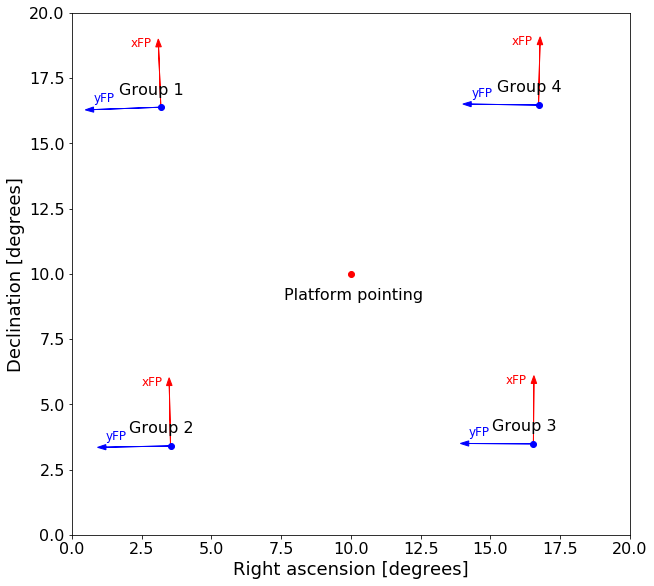

In [33]:
# Camera group info

sim = Simulation("dummy", inputFile)
azimuthAngles = np.array(sim["CameraGroups/AzimuthAngle"])
tiltAngles = np.array(sim["CameraGroups/TiltAngle"])
focalPlaneAngles = np.zeros(4)

NnormalCameraGroups = 4

# Layout

fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(111)
ax.tick_params(axis='both', which='major', labelsize=16)
fig.subplots_adjust(top=0.85)
ax.set_xlabel('Right ascension [degrees]', fontsize = 18)
ax.set_ylabel('Declination [degrees]', fontsize = 18)

offsetX = -1.5
offsetY = 0.5

# Platform pointing

ax.plot([raPlatform], [decPlatform], "ro")
ax.text(raPlatform -2.4, decPlatform -1, r'Platform pointing', fontsize=16)

# Telescope pointing

ax.plot(raTelescopePointings, decTelescopePointings, "bo")

for index in range(NnormalCameraGroups):
   ax.text(raTelescopePointings[index] + offsetX,     \
           decTelescopePointings[index] + offsetY,    \
           "Group " + str(index + 1), fontsize = 16)

# Focal plane axes of each normal camera group

for group in range(NnormalCameraGroups):
    
    raTel= raTelescopePointings[group]
    decTel = decTelescopePointings[group]
    
    xFP, yFP = (10, 0)
    raXaxis, decXaxis = rf.focalPlaneToSkyCoordinates(xFP, yFP, radians(raPlatform), radians(decPlatform),        \
                                                      radians(solarPanelOrientation), radians(tiltAngles[group]), \
                                                      radians(azimuthAngles[group]),                              \
                                                      radians(focalPlaneAngles[group]), focalLength)
    deltaRA = degrees(raXaxis) - raTel
    deltaDec = degrees(decXaxis) - decTel
    plt.arrow(raTel, decTel, deltaRA, deltaDec, head_width=0.2, color="r")
    ax.text(degrees(raXaxis)-1., degrees(decXaxis), "xFP", fontsize=12, color="r")
    
    xFP, yFP = (0, 10)
    raYaxis, decYaxis = rf.focalPlaneToSkyCoordinates(xFP, yFP, radians(raPlatform), radians(decPlatform),         \
                                                      radians(solarPanelOrientation), radians(tiltAngles[group]),  \
                                                      radians(azimuthAngles[group]),                               \
                                                      radians(focalPlaneAngles[group]), focalLength) 
    deltaRA = degrees(raYaxis) - raTel
    deltaDec = degrees(decYaxis) - decTel
    plt.arrow(raTel, decTel, deltaRA, deltaDec, head_width=0.2, color="b")
    ax.text(degrees(raYaxis), degrees(decYaxis)+0.3, "yFP", fontsize=12, color="b")

plt.xlim([0, 20])
plt.ylim([0, 20])

### Which CCD was Selected by which Telescope (Group)?

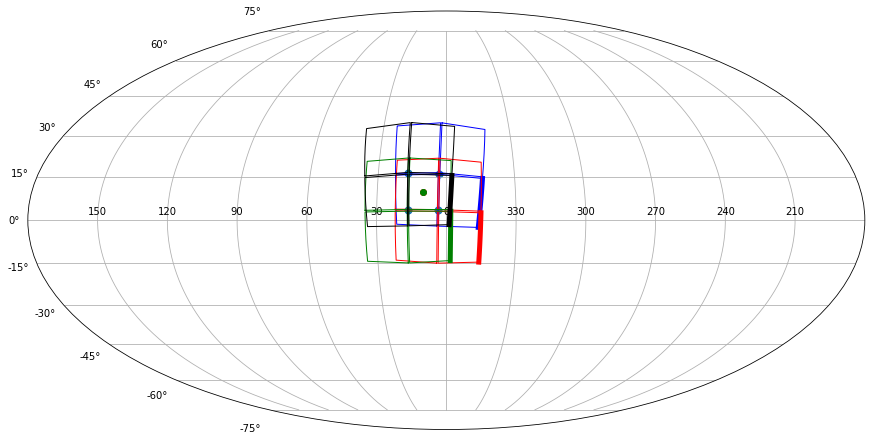

In [34]:
fig = plt.figure(figsize = (15, 15))
axes = fig.add_subplot(111, projection="mollweide")
axes.grid(True)

sim = Simulation("dummy", inputFile)
azimuthAngles = sim["CameraGroups/AzimuthAngle"]
tiltAngles = sim["CameraGroups/TiltAngle"]

ccdCodes = ['1', '2', '3', '4']
    
for group in range(0,4):
    
    focalPlaneAngle = 0.0
    
    # Set up the colors to be used to draw each CCD. 
    # Different CCDs have different colors.

    #color = {'A': 'b', 'AF': 'b', 'B': 'r', 'BF': 'r', 'C': 'g', 'CF': 'g', 'D': 'k', 'DF': 'k'}
    color = ['b', 'r', 'g', 'k']
    
    # Plot each of the 4 CCDs

    for ccdCode in ccdCodes:

        # Get the focal plane FP' coordinates of the CCD corners  [mm]

        cornersXmm, cornersYmm = rf.computeCCDcornersInFocalPlane(ccdCode, pixelSize)

        # Compute the equatorial sky coordinates [rad] from the the focal plane FP' coordinates [mm] of the corners

        ra, dec = rf.focalPlaneToSkyCoordinates(cornersXmm, cornersYmm, radians(raPlatform), radians(decPlatform), 
                                                radians(solarPanelOrientation), radians(tiltAngles[group]), 
                                                radians(azimuthAngles[group]), radians(focalPlaneAngle), focalLength)
                
        # Repeat the coordinates of the 1st corner, to plot a nice closed loop

        ra  = np.append(ra, ra[0])
        dec = np.append(dec, dec[0])

        # The sky projection assumes a longitude in [-pi, +pi] rather than [0, 2* pi]
        # And the longitude should be reversed so that East is to the left
        
        ra[ra>np.pi] -= 2*np.pi
        ra = -ra
 
        # Plot the CCD
    
        axes.plot(ra, dec, c=color[group], linewidth=1)

        # Overplot the row closest to the readout register with a thicker line

        if ccdCode == '1':
            axes.plot([ra[0], ra[1]], [dec[0], dec[1]], c=color[group], linewidth=5)
        

# Adapt the tick labels on the x-axis to take into account the origin shift
    
tickLabels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
tickLabels = np.remainder(tickLabels+360, 360)
axes.set_xticklabels(tickLabels)      

# Overplot the telescope pointing and the platform pointing

plt.scatter(np.deg2rad(-raTelescopePointings), np.deg2rad(decTelescopePointings), s=50)
plt.plot(np.deg2rad([-raPlatform]), np.deg2rad([decPlatform]), "ro")
plt.plot(np.deg2rad([-raSubfield]), np.deg2rad([decSubfield]), "go")

## Telescope group 1: CCD 2 selected

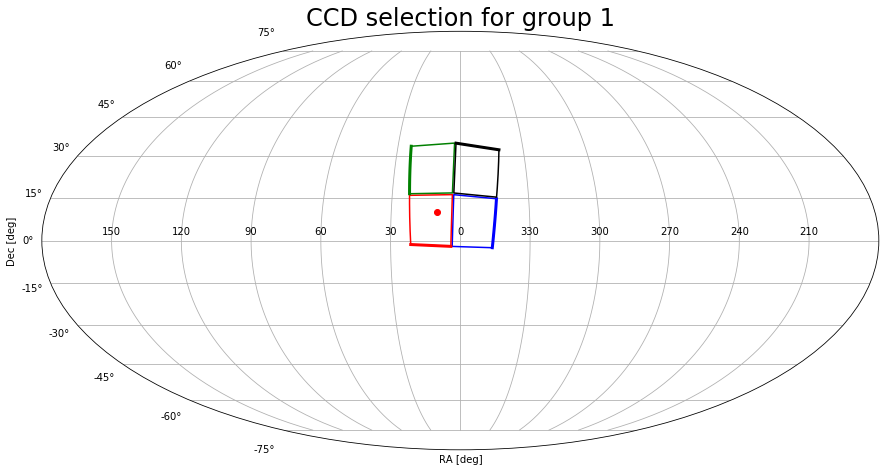

In [39]:
fig = plt.figure(figsize = (15, 15))
focalPlaneAngle = 0.0
axes = plot.drawCCDsInSkyMollweide(fig, radians(raPlatform), radians(decPlatform), solarPanelOrientation,            \
                                   radians(tiltAngles[0]), radians(azimuthAngles[0]), radians(focalPlaneAngle), \
                                   focalLength, pixelSize, normal=True)

plt.title('CCD selection for group 1', fontsize = 24)
axes.plot(np.deg2rad([-raSubfield]), np.deg2rad([decSubfield]), "ro")

## Telescope group 2: CCD 3 selected

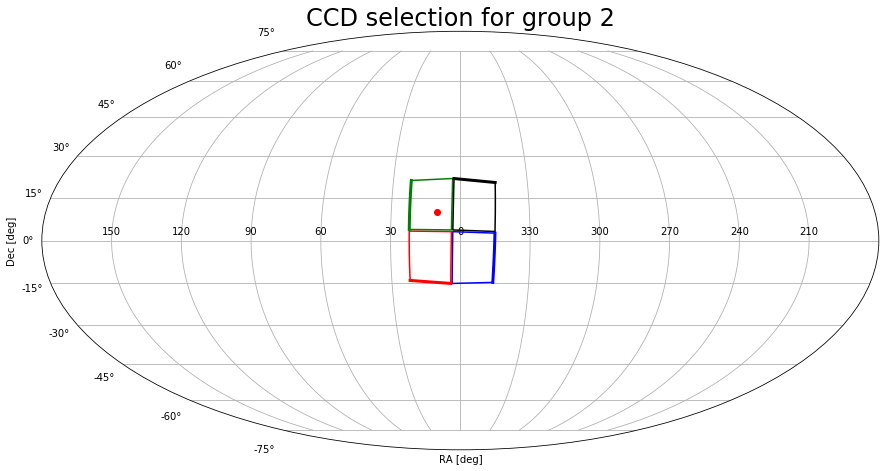

In [40]:
fig = plt.figure(figsize = (15, 15))
focalPlaneAngle = 0.0
axes = plot.drawCCDsInSkyMollweide(fig, radians(raPlatform), radians(decPlatform), solarPanelOrientation,         \
                              radians(tiltAngles[1]), radians(azimuthAngles[1]), radians(focalPlaneAngle),   \
                              focalLength, pixelSize, normal=True)

plt.title('CCD selection for group 2', fontsize = 24)
axes.plot(np.deg2rad([-raSubfield]), np.deg2rad([decSubfield]), "ro")

## Telescope group 3: CCD 4 selected

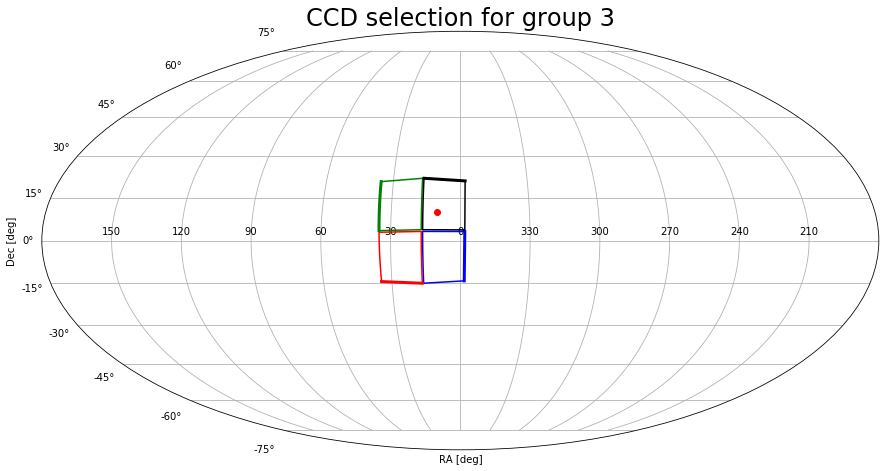

In [41]:
fig = plt.figure(figsize = (15, 15))
focalPlaneAngle = 0.0
axes = plot.drawCCDsInSkyMollweide(fig, radians(raPlatform), radians(decPlatform), solarPanelOrientation,       \
                              radians(tiltAngles[2]), radians(azimuthAngles[2]), radians(focalPlaneAngle),  \
                              focalLength, pixelSize, normal=True)

plt.title('CCD selection for group 3', fontsize = 24)
axes.plot(np.deg2rad([-raSubfield]), np.deg2rad([decSubfield]), "ro")

# Telescope group 4: CCD 1 selected

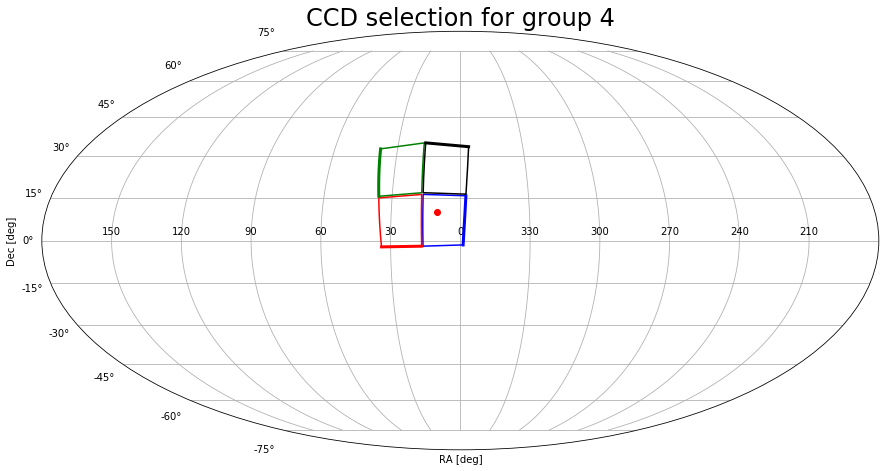

In [42]:
fig = plt.figure(figsize = (15, 15))
focalPlaneAngle = 0.0
axes = plot.drawCCDsInSkyMollweide(fig, radians(raPlatform), radians(decPlatform), solarPanelOrientation,         \
                              radians(tiltAngles[3]), radians(azimuthAngles[3]), radians(focalPlaneAngle),   \
                              focalLength, pixelSize, normal=True)

plt.title('CCD selection for group 4', fontsize = 24)
axes.plot(np.deg2rad([-raSubfield]), np.deg2rad([decSubfield]), "ro")